In [39]:
# Librerias
from pathlib import Path
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
try:
    ROOT = Path(__file__).resolve().parents[1]          
except NameError:                                      
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

BRONZE = ROOT / "data" / "bronze" / "meteorologicos_aranzazu_raw.csv"
SILVER_DIR = ROOT / "data" / "silver" 
SILVER = SILVER_DIR / "meteorologicos_aranzazu_silver.csv"

## **Datos**

In [2]:
aranzazu = pd.read_csv('../data/bronze/meteorologicos_aranzazu_raw.csv', encoding='utf8')

In [3]:
aranzazu.head(5)

,Time,Interval,Indoor Temperature(°C),Indoor Humidity(%),Outdoor Temperature(°C),Outdoor Humidity(%),Relative Pressure(hpa),Absolute Pressure(hpa),Wind Speed(km/h),Gust(km/h),Wind Direction,DewPoint(°C),WindChill(°C),Hour Rainfall(mm),24 Hour Rainfall(mm),Week Rainfall(mm),Month Rainfall(mm),Total Rainfall(mm),Light(lux),UVI
0,2018/01/01 1:02:06 a.m.,60,"20,8",74,"16,1",93,1.013,"826,7","1,1","3,6",S,15,"16,1",0,0,"12,9",0,"437,1",0,0
1,2018/01/01 2:02:06 a.m.,60,"20,8",74,"16,2",93,"1.012,2","825,9",0,0,E,"15,1","16,2",0,0,"12,9",0,"437,1",0,0
2,2018/01/01 3:02:06 a.m.,60,"20,6",75,"15,9",95,1.012,"825,7",0,0,NW,"15,1","15,9",0,0,"12,9",0,"437,1",0,0
3,2018/01/01 4:02:06 a.m.,60,"20,5",74,16,95,"1.011,7","825,4",0,"1,1",SE,"15,2",16,0,0,"12,9",0,"437,1",0,0
4,2018/01/01 5:02:06 a.m.,60,"20,5",75,"15,6",95,1.012,"825,7","1,1","2,5",S,"14,8","15,6",0,0,"12,9",0,"437,1",0,0


In [4]:
aranzazu.info()

<class 'pandas.DataFrame'>
RangeIndex: 19190 entries, 0 to 19189
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Time                     19190 non-null  str  
 1   Interval                 19190 non-null  int64
 2   Indoor Temperature(°C)   19190 non-null  str  
 3   Indoor Humidity(%)       19190 non-null  int64
 4   Outdoor Temperature(°C)  19190 non-null  str  
 5   Outdoor Humidity(%)      19190 non-null  int64
 6   Relative Pressure(hpa)   19190 non-null  str  
 7   Absolute Pressure(hpa)   19190 non-null  str  
 8   Wind Speed(km/h)         19190 non-null  str  
 9   Gust(km/h)               19190 non-null  str  
 10  Wind Direction           19190 non-null  str  
 11  DewPoint(°C)             19190 non-null  str  
 12  WindChill(°C)            19190 non-null  str  
 13  Hour Rainfall(mm)        19190 non-null  str  
 14  24 Hour Rainfall(mm)     19190 non-null  str  
 15  Week Rainfall

> **Hallazgos:**  
> - Variables numéricas (mediciones meteorologicas) codificadas como `str`.
> - Variable de tiempo codificada como `str`.

## **Limpieza**

### **Convertir `Time` a variable de tiempo**

In [5]:
aranzazu["Time_dt"] = pd.to_datetime(
    aranzazu["Time"], format="mixed",
    dayfirst=False, errors="coerce")

In [6]:
type(aranzazu['Time_dt'][1])

pandas.Timestamp

In [7]:
aranzazu[["Time", "Time_dt"]].head(10)

,Time,Time_dt
0,2018/01/01 1:02:06 a.m.,2018-01-01 01:02:06
1,2018/01/01 2:02:06 a.m.,2018-01-01 02:02:06
2,2018/01/01 3:02:06 a.m.,2018-01-01 03:02:06
3,2018/01/01 4:02:06 a.m.,2018-01-01 04:02:06
4,2018/01/01 5:02:06 a.m.,2018-01-01 05:02:06
5,2018/01/01 6:02:06 a.m.,2018-01-01 06:02:06
6,2018/01/01 7:02:06 a.m.,2018-01-01 07:02:06
7,2018/01/01 8:02:06 a.m.,2018-01-01 08:02:06
8,2018/01/01 9:02:06 a.m.,2018-01-01 09:02:06
9,2018/01/01 10:02:06 a.m.,2018-01-01 10:02:06


**Corregir la variable time**

In [8]:
def leer_fecha(texto):
    t = (texto.replace("a. m.", "AM").replace("p. m.", "PM")
              .replace("a.m.", "AM").replace("p.m.", "PM"))
    if re.match(r"^\d{4}-\d{2}-\d{2}T", t):        # 2019-09-01T13:27:08.000
        return pd.to_datetime(t, errors="coerce")
    if re.match(r"^\d{4}/", t):                    # 2018/01/01 1:02:06 AM
        return pd.to_datetime(t, format="%Y/%m/%d %I:%M:%S %p", errors="coerce")
    return pd.to_datetime(t, format="%d/%m/%Y %I:%M:%S %p", errors="coerce")  # 1/05/2019 ...

aranzazu["Time_dt"] = aranzazu["Time"].map(leer_fecha)
print("fechas vacías:", aranzazu["Time_dt"].isna().sum())   # debe dar 0

fechas vacías: 0


In [9]:
aranzazu = aranzazu.drop(columns=['Time'])
aranzazu.columns

Index(['Interval', 'Indoor Temperature(°C)', 'Indoor Humidity(%)',
       'Outdoor Temperature(°C)', 'Outdoor Humidity(%)',
       'Relative Pressure(hpa)', 'Absolute Pressure(hpa)', 'Wind Speed(km/h)',
       'Gust(km/h)', 'Wind Direction', 'DewPoint(°C)', 'WindChill(°C)',
       'Hour Rainfall(mm)', '24 Hour Rainfall(mm)', 'Week Rainfall(mm)',
       'Month Rainfall(mm)', 'Total Rainfall(mm)', 'Light(lux)', 'UVI',
       'Time_dt'],
      dtype='str')

### **Conversión de variables numéricas originalmente codificadas como `str`**

In [10]:
numeric_cols = [
    "Indoor Temperature(°C)",
    "Outdoor Temperature(°C)",
    "Relative Pressure(hpa)",
    "Absolute Pressure(hpa)",
    "Wind Speed(km/h)",
    "Gust(km/h)",
    "DewPoint(°C)",
    "WindChill(°C)",
    "Hour Rainfall(mm)",
    "24 Hour Rainfall(mm)",
    "Week Rainfall(mm)",
    "Month Rainfall(mm)",
    "Total Rainfall(mm)",
    "Light(lux)"]

for col in numeric_cols:
    aranzazu[col] = (
        aranzazu[col]
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False))
    aranzazu[col] = pd.to_numeric(aranzazu[col], errors="coerce")

for col in numeric_cols:
    aranzazu[col] = pd.to_numeric(aranzazu[col], errors="coerce")

missing = aranzazu.isna().sum().sort_values(ascending=False)
missing

Interval                   0
Indoor Temperature(°C)     0
Indoor Humidity(%)         0
Outdoor Temperature(°C)    0
Outdoor Humidity(%)        0
Relative Pressure(hpa)     0
Absolute Pressure(hpa)     0
Wind Speed(km/h)           0
Gust(km/h)                 0
Wind Direction             0
DewPoint(°C)               0
WindChill(°C)              0
Hour Rainfall(mm)          0
24 Hour Rainfall(mm)       0
Week Rainfall(mm)          0
Month Rainfall(mm)         0
Total Rainfall(mm)         0
Light(lux)                 0
UVI                        0
Time_dt                    0
dtype: int64

In [11]:
aranzazu.head(5)

,Interval,Indoor Temperature(°C),Indoor Humidity(%),Outdoor Temperature(°C),Outdoor Humidity(%),Relative Pressure(hpa),Absolute Pressure(hpa),Wind Speed(km/h),Gust(km/h),Wind Direction,DewPoint(°C),WindChill(°C),Hour Rainfall(mm),24 Hour Rainfall(mm),Week Rainfall(mm),Month Rainfall(mm),Total Rainfall(mm),Light(lux),UVI,Time_dt
0,60,20.8,74,16.1,93,1013.0,826.7,1.1,3.6,S,15.0,16.1,0.0,0.0,12.9,0.0,437.1,0.0,0,2018-01-01 01:02:06
1,60,20.8,74,16.2,93,1012.2,825.9,0.0,0.0,E,15.1,16.2,0.0,0.0,12.9,0.0,437.1,0.0,0,2018-01-01 02:02:06
2,60,20.6,75,15.9,95,1012.0,825.7,0.0,0.0,NW,15.1,15.9,0.0,0.0,12.9,0.0,437.1,0.0,0,2018-01-01 03:02:06
3,60,20.5,74,16.0,95,1011.7,825.4,0.0,1.1,SE,15.2,16.0,0.0,0.0,12.9,0.0,437.1,0.0,0,2018-01-01 04:02:06
4,60,20.5,75,15.6,95,1012.0,825.7,1.1,2.5,S,14.8,15.6,0.0,0.0,12.9,0.0,437.1,0.0,0,2018-01-01 05:02:06


In [12]:
aranzazu.info()

<class 'pandas.DataFrame'>
RangeIndex: 19190 entries, 0 to 19189
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Interval                 19190 non-null  int64         
 1   Indoor Temperature(°C)   19190 non-null  float64       
 2   Indoor Humidity(%)       19190 non-null  int64         
 3   Outdoor Temperature(°C)  19190 non-null  float64       
 4   Outdoor Humidity(%)      19190 non-null  int64         
 5   Relative Pressure(hpa)   19190 non-null  float64       
 6   Absolute Pressure(hpa)   19190 non-null  float64       
 7   Wind Speed(km/h)         19190 non-null  float64       
 8   Gust(km/h)               19190 non-null  float64       
 9   Wind Direction           19190 non-null  str           
 10  DewPoint(°C)             19190 non-null  float64       
 11  WindChill(°C)            19190 non-null  float64       
 12  Hour Rainfall(mm)        19190 non-null  fl

### **Conversión de Nulos de `Wind Direction` codificados como `---`, a `NaN`**

In [13]:
aranzazu['Wind Direction'].unique()

<StringArray>
[  'S',   'E',  'NW',  'SE',  'NE', 'ENE',   'N',  'SW',   'W', 'NNW', 'SSW',
 'WNW', 'WSW', 'NNE', 'SSE', '---']
Length: 16, dtype: str

In [14]:
# Registros nulos de `Wind Direction`
aranzazu[aranzazu['Wind Direction'] == '---']

,Interval,Indoor Temperature(°C),Indoor Humidity(%),Outdoor Temperature(°C),Outdoor Humidity(%),Relative Pressure(hpa),Absolute Pressure(hpa),Wind Speed(km/h),Gust(km/h),Wind Direction,DewPoint(°C),WindChill(°C),Hour Rainfall(mm),24 Hour Rainfall(mm),Week Rainfall(mm),Month Rainfall(mm),Total Rainfall(mm),Light(lux),UVI,Time_dt
6260,30,22.4,68,22.4,62,1011.5,826.2,11.2,15.8,---,14.8,20.9,0.0,0.0,6.0,98.4,149.4,45814.0,0,2018-08-31 09:06:48
8211,30,25.1,47,22.6,52,1010.6,825.3,3.6,7.2,---,12.3,22.6,0.0,19.2,51.0,96.3,364.8,19696.1,0,2018-10-11 17:21:42
12403,30,26.0,58,27.4,49,1012.3,827.0,7.2,9.7,---,15.8,27.1,0.0,0.0,32.7,38.1,1629.9,80932.4,0,2019-02-15 11:53:46


In [15]:
# Conversión
aranzazu = aranzazu.replace("---", np.nan)
aranzazu.info()

<class 'pandas.DataFrame'>
RangeIndex: 19190 entries, 0 to 19189
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Interval                 19190 non-null  int64         
 1   Indoor Temperature(°C)   19190 non-null  float64       
 2   Indoor Humidity(%)       19190 non-null  int64         
 3   Outdoor Temperature(°C)  19190 non-null  float64       
 4   Outdoor Humidity(%)      19190 non-null  int64         
 5   Relative Pressure(hpa)   19190 non-null  float64       
 6   Absolute Pressure(hpa)   19190 non-null  float64       
 7   Wind Speed(km/h)         19190 non-null  float64       
 8   Gust(km/h)               19190 non-null  float64       
 9   Wind Direction           19187 non-null  str           
 10  DewPoint(°C)             19190 non-null  float64       
 11  WindChill(°C)            19190 non-null  float64       
 12  Hour Rainfall(mm)        19190 non-null  fl

In [16]:
print(aranzazu['Wind Direction'].unique())

aranzazu[aranzazu['Wind Direction'] == '---']

<StringArray>
[  'S',   'E',  'NW',  'SE',  'NE', 'ENE',   'N',  'SW',   'W', 'NNW', 'SSW',
 'WNW', 'WSW', 'NNE', 'SSE',   nan]
Length: 16, dtype: str


,Interval,Indoor Temperature(°C),Indoor Humidity(%),Outdoor Temperature(°C),Outdoor Humidity(%),Relative Pressure(hpa),Absolute Pressure(hpa),Wind Speed(km/h),Gust(km/h),Wind Direction,DewPoint(°C),WindChill(°C),Hour Rainfall(mm),24 Hour Rainfall(mm),Week Rainfall(mm),Month Rainfall(mm),Total Rainfall(mm),Light(lux),UVI,Time_dt


### **Eliminación de la variable `UVI`**

In [17]:
aranzazu['UVI'].unique()

array([0])

In [18]:
# Eliminación de la columna `UVI`
aranzazu = aranzazu.drop(columns=['UVI'])
aranzazu.columns

Index(['Interval', 'Indoor Temperature(°C)', 'Indoor Humidity(%)',
       'Outdoor Temperature(°C)', 'Outdoor Humidity(%)',
       'Relative Pressure(hpa)', 'Absolute Pressure(hpa)', 'Wind Speed(km/h)',
       'Gust(km/h)', 'Wind Direction', 'DewPoint(°C)', 'WindChill(°C)',
       'Hour Rainfall(mm)', '24 Hour Rainfall(mm)', 'Week Rainfall(mm)',
       'Month Rainfall(mm)', 'Total Rainfall(mm)', 'Light(lux)', 'Time_dt'],
      dtype='str')

In [21]:
aranzazu = aranzazu.sort_values("Time_dt").drop_duplicates("Time_dt").set_index("Time_dt")
print(aranzazu.index.is_monotonic_increasing, aranzazu.index.min(), aranzazu.index.max())


True 2018-01-01 01:02:06 2019-09-11 17:57:08


## **EDA**

### **Faltantes**

Únicamente se reportan faltantes en la variable `Wind Direction`.

In [19]:
# Tabla de valores faltantes del dataset Aranzazu

faltantes = aranzazu['Wind Direction'].isna().sum()

porcentaje_faltantes = (faltantes / len(aranzazu)) * 100

tabla_faltantes = pd.DataFrame({
    "Variable": ["Wind Direction"],
    "Valores faltantes": [faltantes],
    "Porcentaje (%)": [porcentaje_faltantes.round(2)]
})

tabla_faltantes

,Variable,Valores faltantes,Porcentaje (%)
0,Wind Direction,3,0.02


### **Valores imposibles**
Son valores que aparecen en la base de datos que no pueden ser reales

In [22]:
reglas = {
    "Temperatura exterior > 40 °C": aranzazu["Outdoor Temperature(°C)"] > 40,
    "Temperatura interior > 40 °C": aranzazu["Indoor Temperature(°C)"] > 40,
    "Presión relativa > 1100 hPa": aranzazu["Relative Pressure(hpa)"] > 1100,
    "Presión absoluta < 700 hPa":  aranzazu["Absolute Pressure(hpa)"] < 700,
    "Lluvia en una hora > 100 mm": aranzazu["Hour Rainfall(mm)"] > 100,
    "Luz > 200.000 lux":           aranzazu["Light(lux)"] > 200000}

tabla_imposibles = pd.DataFrame({"Regla": list(reglas),
                                 "Registros": [int(r.sum()) for r in reglas.values()]})
tabla_imposibles

,Regla,Registros
0,Temperatura exterior > 40 °C,485
1,Temperatura interior > 40 °C,485
2,Presión relativa > 1100 hPa,485
3,Presión absoluta < 700 hPa,485
4,Lluvia en una hora > 100 mm,1
5,Luz > 200.000 lux,2


In [24]:
danada = aranzazu["Outdoor Temperature(°C)"] > 40
aranzazu.loc[danada, :] = np.nan
aranzazu.loc[aranzazu["Hour Rainfall(mm)"] > 100, "Hour Rainfall(mm)"] = np.nan
aranzazu.loc[aranzazu["Light(lux)"] > 200000, "Light(lux)"] = np.nan

### **Diagnostico para saber que tenemos una base de datos limpia**

In [26]:
def diagnostico(df):
    print("1. fechas vacías :", df.index.isna().sum())
    print("2. índice ordenado :", df.index.is_monotonic_increasing)
    print("3. fechas repetidas :", df.index.duplicated().sum())
    print("4. primera y última fecha:", df.index.min(), "|", df.index.max())
    esperado = {"Indoor Temperature(°C)": 31, "Outdoor Temperature(°C)": 31,
                "Relative Pressure(hpa)": 1020, "Absolute Pressure(hpa)": 830,
                "DewPoint(°C)": 21, "WindChill(°C)": 31,
                "Hour Rainfall(mm)": 27, "Light(lux)": 110000}
    malas = [c for c, lim in esperado.items() if c in df and df[c].max() > lim]
    print("5. columnas con máximos imposibles (debe estar vacía):", malas)
    print("6. columnas no numéricas:", [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])])
    print("7. filas:", len(df), "| columnas:", df.shape[1])
    print("8. faltantes por columna:\n", df.isna().sum()[df.isna().sum() > 0].to_string())

diagnostico(aranzazu)

1. fechas vacías : 0
2. índice ordenado : True
3. fechas repetidas : 0
4. primera y última fecha: 2018-01-01 01:02:06 | 2019-09-11 17:57:08
5. columnas con máximos imposibles (debe estar vacía): []
6. columnas no numéricas: ['Wind Direction']
7. filas: 19190 | columnas: 18
8. faltantes por columna:
 Interval                   485
Indoor Temperature(°C)     485
Indoor Humidity(%)         485
Outdoor Temperature(°C)    485
Outdoor Humidity(%)        485
Relative Pressure(hpa)     485
Absolute Pressure(hpa)     485
Wind Speed(km/h)           485
Gust(km/h)                 485
Wind Direction             488
DewPoint(°C)               485
WindChill(°C)              485
Hour Rainfall(mm)          486
24 Hour Rainfall(mm)       485
Week Rainfall(mm)          485
Month Rainfall(mm)         485
Total Rainfall(mm)         485
Light(lux)                 487


Si quedo bien, ya no existe ningún valor imposible.

In [41]:
def guardar_silver(df, nombre="meteorologicos_aranzazu_silver.csv", carpeta="../data/silver"):
    ruta = Path(carpeta)
    ruta.mkdir(parents=True, exist_ok=True)
    df.to_csv(ruta / nombre, index_label="Time_dt")
    print("Guardado en:", ruta / nombre, "|", df.shape[0], "filas x", df.shape[1], "columnas")

guardar_silver(aranzazu)

Guardado en: ../data/silver/meteorologicos_aranzazu_silver.csv | 19190 filas x 18 columnas


### **Distribuciones**

### **Resumen numerico**

In [27]:
acumulados = ["24 Hour Rainfall(mm)", "Week Rainfall(mm)", "Month Rainfall(mm)", "Total Rainfall(mm)"]
variables = [c for c in aranzazu.select_dtypes("number").columns
             if c not in ["Interval"] + acumulados]

In [28]:
resumen = aranzazu[variables].describe(percentiles=[.5]).T[["count", "min", "50%", "max", "mean", "std"]]
resumen["asimetria"] = aranzazu[variables].skew()
resumen["%ceros"] = (aranzazu[variables] == 0).mean() * 100
resumen.round(2)

,count,min,50%,max,mean,std,asimetria,%ceros
Indoor Temperature(°C),18705.0,18.5,22.6,30.1,22.93,1.72,0.67,0.00
Indoor Humidity(%),18705.0,34.0,68.0,81.0,66.97,6.63,-1.07,0.00
Outdoor Temperature(°C),18705.0,12.6,18.3,30.3,19.41,3.24,0.69,0.00
Outdoor Humidity(%),18705.0,23.0,84.0,99.0,80.21,13.94,-0.76,0.00
Relative Pressure(hpa),18705.0,997.0,1011.6,1017.7,1010.67,4.08,-1.44,0.00
Absolute Pressure(hpa),18705.0,820.6,826.0,829.8,825.95,1.31,-0.21,0.00
Wind Speed(km/h),18705.0,0.0,2.5,23.4,2.69,2.61,1.28,21.95
Gust(km/h),18705.0,0.0,3.6,36.7,4.65,3.51,1.29,6.97
DewPoint(°C),18705.0,4.7,15.8,20.1,15.63,1.27,-0.91,0.00
WindChill(°C),18705.0,11.8,18.3,30.3,19.33,3.20,0.68,0.00


Ya nos damos cuenta de que quedo bien limpia la base de datos, pero tenemos que tener en cuenta que la luz tiene distintas escalas y para KNN es necesario escalarlas. 

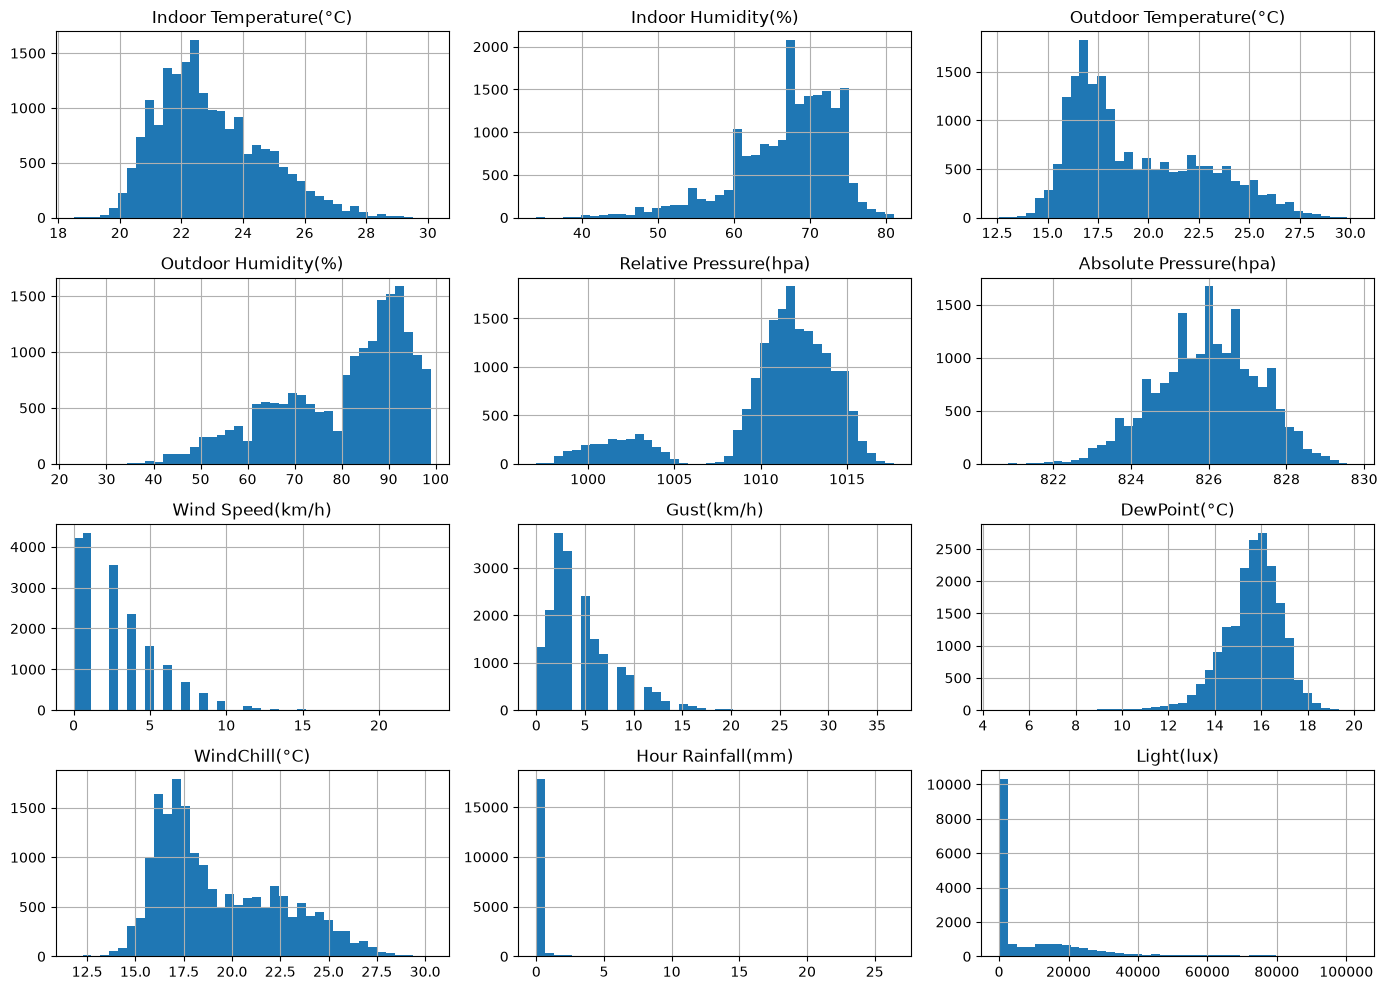

In [29]:
aranzazu[variables].hist(bins=40, figsize=(14, 10))
plt.tight_layout()
plt.show()

### **Correlaciones**

### **Correlación de Spearman**

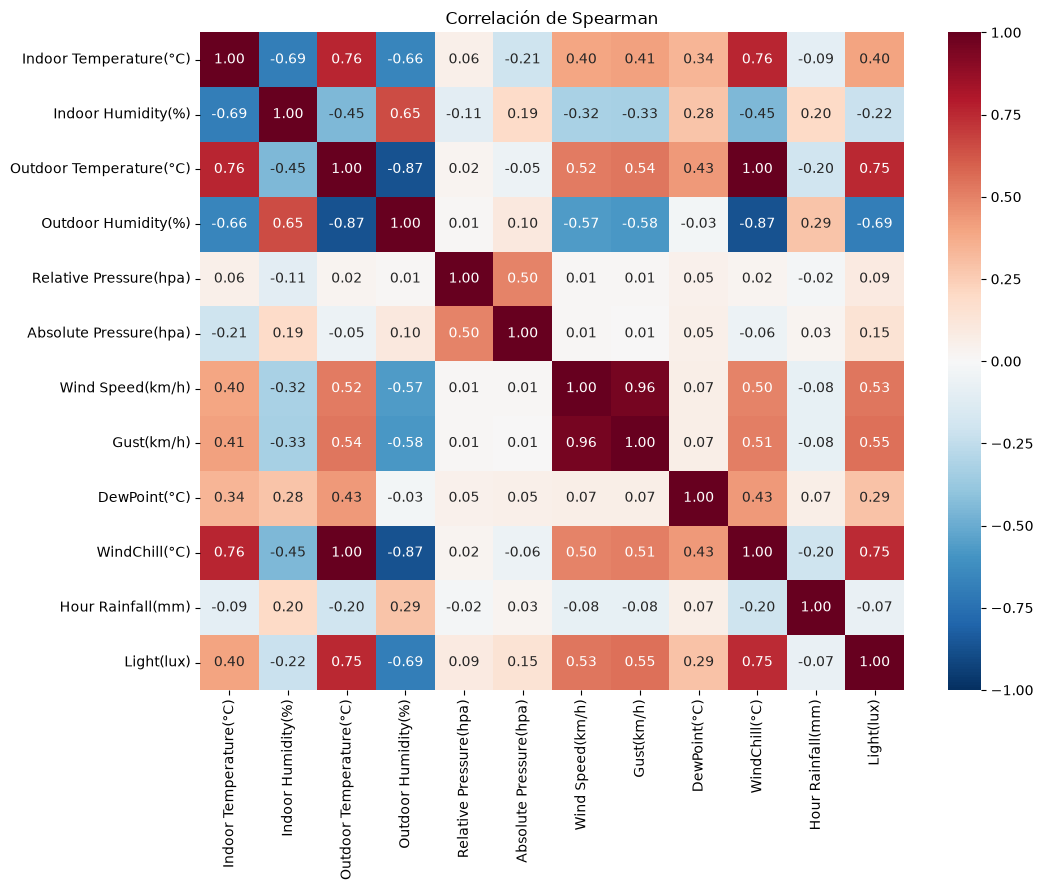

Outdoor Temperature(°C)  WindChill(°C)              1.00
Wind Speed(km/h)         Gust(km/h)                 0.96
Outdoor Temperature(°C)  Outdoor Humidity(%)       -0.87
Outdoor Humidity(%)      WindChill(°C)             -0.87
Indoor Temperature(°C)   Outdoor Temperature(°C)    0.76
                         WindChill(°C)              0.76
Outdoor Temperature(°C)  Light(lux)                 0.75
WindChill(°C)            Light(lux)                 0.75
Outdoor Humidity(%)      Light(lux)                -0.69
Indoor Temperature(°C)   Indoor Humidity(%)        -0.69
                         Outdoor Humidity(%)       -0.66
Indoor Humidity(%)       Outdoor Humidity(%)        0.65
dtype: float64


In [30]:
corr = aranzazu[variables].corr(method="spearman")

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Correlación de Spearman")
plt.tight_layout()
plt.show()

pares = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().dropna()
print(pares.sort_values(key=abs, ascending=False).head(12).round(2))

In [35]:
R, A = "Relative Pressure(hpa)", "Absolute Pressure(hpa)"
mes = aranzazu.index.to_period("M")

por_mes = pd.DataFrame({
    "spearman": aranzazu[[R, A]].groupby(mes).apply(lambda g: g[R].rank().corr(g[A].rank())),
    "diferencia_mediana_hPa": (aranzazu[R] - aranzazu[A]).groupby(mes).median(),
}).round(2)
print(por_mes)

         spearman  diferencia_mediana_hPa
Time_dt                                  
2018-01      1.00                   186.3
2018-02      1.00                   189.9
2018-03      0.60                   186.4
2018-04      0.57                   173.8
2018-05      1.00                   173.8
2018-06      1.00                   177.0
2018-07      1.00                   177.0
2018-08      1.00                   185.3
2018-09      1.00                   185.3
2018-10      1.00                   185.3
2018-11      1.00                   185.3
2018-12      1.00                   185.3
2019-01      1.00                   185.3
2019-02      1.00                   185.3
2019-03      1.00                   185.3
2019-04      1.00                   185.3
2019-05      1.00                   187.4
2019-06      1.00                   187.4
2019-07      1.00                   187.4
2019-08      1.00                   187.4
2019-09       NaN                     NaN


Para observar las correlaciones sin los valores de la base de datos que son imposibles de que ocurran, observamos las correlaciones por tramos.

In [37]:
def tramos(df, cols, max_salto_min=65):
    d = df.sort_index()
    t = d.index.to_series()
    ok = d[cols].notna().all(axis=1)
    salto = t.diff() > pd.Timedelta(minutes=max_salto_min)
    nuevo = salto | ~ok.shift(fill_value=False)   # empieza un tramo tras un hueco o un nulo
    grupo = nuevo.cumsum()
    out = t[ok].groupby(grupo[ok]).agg(n="size", ini="min", fin="max")
    return out.sort_values("n", ascending=False).reset_index(drop=True)

r = tramos(aranzazu, variables)
print("Tramos con 1000 o más registros:", (r["n"] >= 1000).sum())
print(r.head(8))

Tramos con 1000 o más registros: 6
      n                 ini                 fin
0  1484 2019-05-01 01:16:58 2019-05-31 23:45:58
1  1413 2018-11-01 01:00:22 2018-11-30 11:49:22
2  1242 2019-02-03 02:51:46 2019-02-28 23:53:46
3  1205 2018-12-06 09:01:53 2018-12-31 11:54:53
4  1145 2018-09-06 15:46:42 2018-09-30 11:46:42
5  1005 2018-10-02 12:51:42 2018-10-23 10:51:42
6   966 2018-08-01 01:20:48 2018-08-21 04:20:48
7   922 2019-08-03 12:22:34 2019-08-22 17:22:34


Ahora comparamos el tramo principal(El más grande), con la base de datos completa.

In [38]:
principal = r.iloc[0]
tramo = aranzazu.loc[principal["ini"]:principal["fin"]]
print("Tramo principal:", principal["ini"], "->", principal["fin"], "| registros:", len(tramo))

mascara = np.triu(np.ones(corr.shape, dtype=bool), k=1)
corr_tramo = tramo[variables].corr(method="spearman")

comparar = pd.DataFrame({
    "base_completa": corr.where(mascara).stack().dropna(),
    "tramo_principal": corr_tramo.where(mascara).stack().dropna(),
}).round(2)
comparar["cambio"] = (comparar["tramo_principal"] - comparar["base_completa"]).round(2)
print(comparar.sort_values("cambio", key=abs, ascending=False).head(10))

Tramo principal: 2019-05-01 01:16:58 -> 2019-05-31 23:45:58 | registros: 1484
                                                base_completa  \
Relative Pressure(hpa)  Absolute Pressure(hpa)           0.50   
Indoor Humidity(%)      Relative Pressure(hpa)          -0.11   
Indoor Temperature(°C)  Relative Pressure(hpa)           0.06   
Indoor Humidity(%)      DewPoint(°C)                     0.28   
Outdoor Humidity(%)     DewPoint(°C)                    -0.03   
Indoor Temperature(°C)  DewPoint(°C)                     0.34   
Outdoor Temperature(°C) DewPoint(°C)                     0.43   
DewPoint(°C)            WindChill(°C)                    0.43   
Indoor Humidity(%)      Absolute Pressure(hpa)           0.19   
Gust(km/h)              DewPoint(°C)                     0.07   

                                                tramo_principal  cambio  
Relative Pressure(hpa)  Absolute Pressure(hpa)             1.00    0.50  
Indoor Humidity(%)      Relative Pressure(hpa)            

### **Revisaremos las variables de tiempo** 
Con la finalidad de  encontrar los tramos mas optimos veremos el ciclo diario por mes

**Ciclo diario por mes**

         hora_pico_luz  hora_pico_temp
Time_dt                               
2018-01             12              12
2018-02             14              14
2018-03             12              14
2018-04             11              12
2018-05             14              14
2018-06             23               0
2018-07             20              21
2018-08             13              14
2018-09             11              13
2018-10             12              13
2018-11             21              22
2018-12             11              14
2019-01             11              15
2019-02             12              14
2019-03             11              14
2019-04             11              17
2019-05             13              15
2019-06             13              15
2019-07             11              15
2019-08              3               5


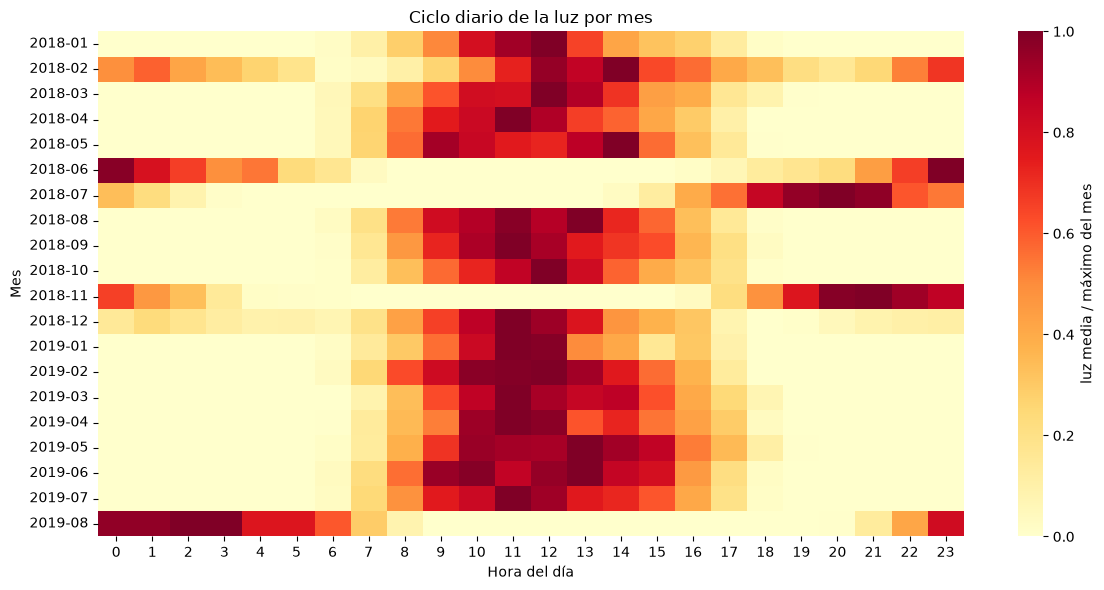

In [42]:
hora = aranzazu.index.hour
mes = aranzazu.index.to_period("M")

luz = aranzazu.groupby([mes, hora])["Light(lux)"].mean().unstack().dropna(how="all")
temp = aranzazu.groupby([mes, hora])["Outdoor Temperature(°C)"].mean().unstack().dropna(how="all")

ciclo = pd.DataFrame({"hora_pico_luz": luz.idxmax(axis=1),
                      "hora_pico_temp": temp.idxmax(axis=1)})
print(ciclo)

plt.figure(figsize=(12, 6))
sns.heatmap(luz.div(luz.max(axis=1), axis=0), cmap="YlOrRd",
            cbar_kws={"label": "luz media / máximo del mes"})
plt.xlabel("Hora del día"); plt.ylabel("Mes")
plt.title("Ciclo diario de la luz por mes")
plt.tight_layout()
plt.show()

De marzo a mayo y de agosto a octubre de 2018, y de enero a julio de 2019. febrero, noviembre, junio de 2018 tienen algo de luz de noche. Puede ser que el reloj cambie dentro del mes, así que habría que revisarlos día por día antes de usarlos. Así como agosto del 2019 se ve luz de noche.

**Huecos en el tiempo**

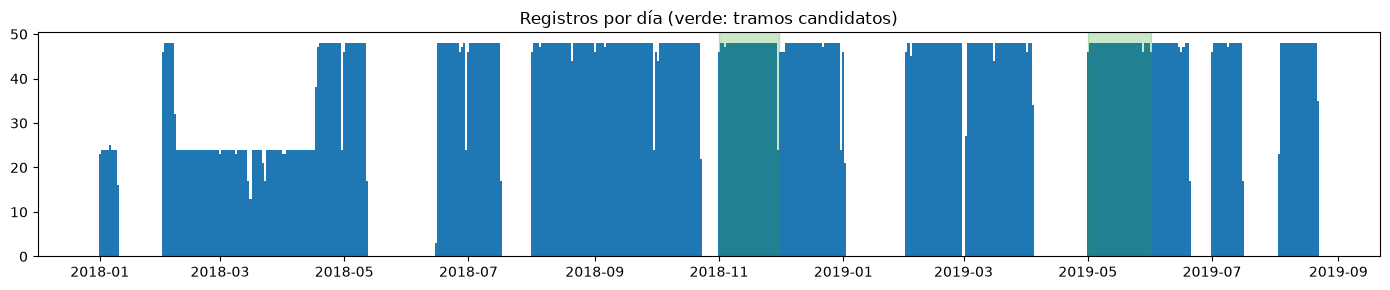

In [43]:
por_dia = aranzazu["Outdoor Temperature(°C)"].dropna().resample("D").size()

plt.figure(figsize=(14, 3))
plt.bar(por_dia.index, por_dia.values, width=1)
for _, f in r.head(2).iterrows():
    plt.axvspan(f["ini"], f["fin"], alpha=0.25, color="tab:green")
plt.title("Registros por día (verde: tramos candidatos)")
plt.tight_layout()
plt.show()

In [44]:
r = tramos(aranzazu, variables, max_salto_min=95)
print(r.head(5))

      n                 ini                 fin
0  2407 2019-05-01 01:16:58 2019-06-20 08:15:58
1  1928 2018-08-21 06:03:48 2018-09-30 11:46:42
2  1413 2018-11-01 01:00:22 2018-11-30 11:49:22
3  1378 2019-03-02 10:51:44 2019-03-31 05:11:44
4  1339 2019-02-01 01:26:46 2019-02-28 23:53:46


Gracias a esto podemos a escoger dos tramos optimos para empezar a hacer los modelos.

### **Elegir los tramos optimos**

In [45]:
r = tramos(aranzazu, variables, max_salto_min=95)
print(r.head(2))

tramo_evaluacion = r.iloc[0]   # 1 may – 20 jun 2019
tramo_ajuste = r.iloc[1]

      n                 ini                 fin
0  2407 2019-05-01 01:16:58 2019-06-20 08:15:58
1  1928 2018-08-21 06:03:48 2018-09-30 11:46:42


Regularizar la base de datos a un intervalo constante de 30 minutos

In [46]:
def regularizar(df, ini, fin):
    t = df.loc[ini:fin, variables].copy()
    t["Time_original"] = t.index                       # se conserva la fecha original
    t.index = t.index.round("30min")                   # a la rejilla de 30 minutos
    t = t[~t.index.duplicated(keep="first")]
    rejilla = pd.date_range(t.index.min(), t.index.max(), freq="30min")
    t = t.reindex(rejilla)                             # los huecos quedan como NaN
    t.index.name = "Time_dt"
    return t

ajuste = regularizar(aranzazu, tramo_ajuste["ini"], tramo_ajuste["fin"])
evaluacion = regularizar(aranzazu, tramo_evaluacion["ini"], tramo_evaluacion["fin"])

for nombre, t in [("ajuste", ajuste), ("evaluacion", evaluacion)]:
    print(nombre, "| filas:", len(t), "| huecos:", int(t["Time_original"].isna().sum()))

ajuste | filas: 1933 | huecos: 5
evaluacion | filas: 2415 | huecos: 8


In [ ]:
GOLD = Path("../data/gold/tramos")
GOLD.mkdir(parents=True, exist_ok=True)

ajuste.to_csv(GOLD / "tramo_ajuste_2018.csv", index_label="Time_dt")
evaluacion.to_csv(GOLD / "tramo_evaluacion_2019.csv", index_label="Time_dt")